In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# 读取数据
df = pd.read_csv('data.csv')

# 替换缺失值表示符
df.replace('-', np.nan, inplace=True)

# 将时间 t 四舍五入到两位小数，解决浮点数精度问题
df['t'] = df['t'].round(2)

# 删除重复的时间步，保留第一个出现的
df = df.drop_duplicates(subset=['t'], keep='first').reset_index(drop=True)

# 生成完整的时间步范围，从 0 到 20，步长为 0.01
t_full = np.arange(0.00, 20.01, 0.01)  # 包含 t=20.00
df_full = pd.DataFrame({'t': t_full})

# 合并原始数据与完整时间步
df = pd.merge(df_full, df, on='t', how='left')

# 对 x 和 y 进行线性插值填补缺失值
df['x'] = df['x'].interpolate(method='linear')
df['y'] = df['y'].interpolate(method='linear')

# 填充仍然缺失的值为0（如果有）
df['x'].fillna(0, inplace=True)
df['y'].fillna(0, inplace=True)

# 确保数据按时间排序
df.sort_values('t', inplace=True)
df.reset_index(drop=True, inplace=True)

# 检查是否有缺失值
assert df.isnull().sum().sum() == 0, "数据中仍存在缺失值！"

# 线性缩放时间 t 到 [0, 1] 范围
df['t_scaled'] = df['t'] / 100.0  # 因为 t_max=20，t_scaled=0.2

# 对 x 和 y 进行标准化
scaler_xy = StandardScaler()
df[['x_scaled', 'y_scaled']] = scaler_xy.fit_transform(df[['x', 'y']])

# 将数据转换为 numpy 数组
data = df[['t_scaled', 'x_scaled', 'y_scaled']].values  # shape: (2001, 3)


In [2]:
import torch
from torch.utils.data import Dataset, DataLoader

class TimeSeriesDataset(Dataset):
    def __init__(self, data, seq_length, pred_length=10):
        """
        data: numpy array, shape (N, 3) 包含 [t_scaled, x_scaled, y_scaled]
        seq_length: 输入序列长度
        pred_length: 预测序列长度（默认为10）
        """
        self.seq_length = seq_length
        self.pred_length = pred_length
        self.data = data
        self.X = []
        self.Y = []
        N = len(data)
        for i in range(N - seq_length - pred_length + 1):
            self.X.append(data[i:i+seq_length, :])  # shape: (seq_length, 3)
            self.Y.append(data[i+seq_length:i+seq_length+pred_length, 1:3].flatten())  # shape: (pred_length*2,)
    
    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return torch.tensor(self.X[idx], dtype=torch.float32), torch.tensor(self.Y[idx], dtype=torch.float32)


In [3]:
# 定义序列长度和预测长度
SEQ_LENGTH = 100   # 输入序列长度
PRED_LENGTH = 10   # 每次预测10个时间步

# 创建数据集
dataset = TimeSeriesDataset(data, SEQ_LENGTH, PRED_LENGTH)

# 确保数据集中有样本
print(f"Total samples in dataset: {len(dataset)}")  # 应输出: Total samples in dataset: 1891

# 划分训练集和验证集（80% 训练，20% 验证）
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

print(f"Training samples: {len(train_dataset)}, Validation samples: {len(val_dataset)}")  
# 应输出: Training samples: 1512, Validation samples: 379


Total samples in dataset: 1893
Training samples: 1514, Validation samples: 379


In [4]:
# 创建数据加载器
BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)


In [5]:
import torch.nn as nn
import torch.optim as optim

class LSTMModel(nn.Module):
    def __init__(self, input_size=3, hidden_size=128, num_layers=3, output_size=20, dropout=0.3):
        super(LSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # LSTM 层
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout)

        # 全连接层
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # 初始化隐藏状态和细胞状态
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)

        # 前向传播 LSTM
        out, _ = self.lstm(x, (h0, c0))  # out: (batch, seq_length, hidden_size)

        # 取最后一个时间步的输出
        out = out[:, -1, :]  # (batch, hidden_size)

        # 全连接层
        out = self.fc(out)  # (batch, output_size)
        return out

# 实例化模型
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = LSTMModel().to(device)

# 定义损失函数和优化器
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)


In [20]:
import numpy as np

# 训练参数
NUM_EPOCHS = 1000
best_val_loss = np.inf
patience = 100  # 增加耐心值
counter = 0

for epoch in range(NUM_EPOCHS):
    model.train()
    train_losses = []
    for X_batch, Y_batch in train_loader:
        X_batch = X_batch.to(device)
        Y_batch = Y_batch.to(device)  # shape: (batch, pred_length*2)
    
        optimizer.zero_grad()
        outputs = model(X_batch)  # 输出形状: (batch, pred_length*2)
    
        loss = criterion(outputs, Y_batch)  # MSE 损失
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())
    
    avg_train_loss = np.mean(train_losses)
    
    # 验证
    model.eval()
    val_losses = []
    with torch.no_grad():
        for X_batch, Y_batch in val_loader:
            X_batch = X_batch.to(device)
            Y_batch = Y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, Y_batch)
            val_losses.append(loss.item())
    avg_val_loss = np.mean(val_losses)
    
    print(f'Epoch [{epoch+1}/{NUM_EPOCHS}], Train Loss: {avg_train_loss:.6f}, Val Loss: {avg_val_loss:.6f}')
    
    # 早停机制
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        counter = 0
        # 保存最佳模型
        torch.save(model.state_dict(), 'best_lstm_model.pth')
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered")
            break

print("Training complete")


Epoch [1/1000], Train Loss: 0.508136, Val Loss: 0.568956
Epoch [2/1000], Train Loss: 0.518775, Val Loss: 0.561353
Epoch [3/1000], Train Loss: 0.478917, Val Loss: 0.550899
Epoch [4/1000], Train Loss: 0.466462, Val Loss: 0.529563
Epoch [5/1000], Train Loss: 0.454480, Val Loss: 0.521381
Epoch [6/1000], Train Loss: 0.444019, Val Loss: 0.513990
Epoch [7/1000], Train Loss: 0.432636, Val Loss: 0.510517
Epoch [8/1000], Train Loss: 0.425967, Val Loss: 0.496671
Epoch [9/1000], Train Loss: 0.712863, Val Loss: 1.021105
Epoch [10/1000], Train Loss: 0.980471, Val Loss: 0.857793
Epoch [11/1000], Train Loss: 0.875390, Val Loss: 0.831773
Epoch [12/1000], Train Loss: 0.852219, Val Loss: 0.837476
Epoch [13/1000], Train Loss: 0.835388, Val Loss: 0.814472
Epoch [14/1000], Train Loss: 0.817877, Val Loss: 0.797633
Epoch [15/1000], Train Loss: 0.798280, Val Loss: 0.789932
Epoch [16/1000], Train Loss: 0.779504, Val Loss: 0.773660
Epoch [17/1000], Train Loss: 0.754346, Val Loss: 0.729030
Epoch [18/1000], Train 

In [21]:
# 加载最佳模型
model.load_state_dict(torch.load('best_lstm_model.pth'))
model.eval()


LSTMModel(
  (lstm): LSTM(3, 128, num_layers=3, batch_first=True, dropout=0.3)
  (fc): Linear(in_features=128, out_features=20, bias=True)
)

In [22]:
# 选择最后 SEQ_LENGTH 步的数据作为起始序列
sequence = df.iloc[-SEQ_LENGTH:][['t_scaled', 'x_scaled', 'y_scaled']].values  # shape: (seq_length, 3)
sequence = torch.tensor(sequence, dtype=torch.float32).unsqueeze(0).to(device)  # shape: (1, seq_length, 3)

# 定义预测步数
future_steps = int((100 - 20) / 0.01)  # 从 t=20 到 t=100，每步0.01，共8000步
batch_predict_steps = 10  # 每次预测10步

predictions = []

for step in range(0, future_steps, batch_predict_steps):
    current_batch_steps = min(batch_predict_steps, future_steps - step)
    
    with torch.no_grad():
        pred = model(sequence)  # (1, pred_length*2)
        pred = pred.cpu().numpy().flatten()[:current_batch_steps*2]  # 取当前批次步数的预测
        predictions.extend(pred)
    
    # 准备新的输入
    last_t_scaled = sequence[0, -1, 0].item()
    new_t_scaled = last_t_scaled + (current_batch_steps * 0.01) / 100.0  # 批次步长缩放
    new_t_scaled = min(new_t_scaled, 1.0)  # 确保 t 不超过 100，即 t_scaled=1.0
    
    # 获取预测的 x 和 y
    for i in range(current_batch_steps):
        pred_x_scaled = pred[2*i]
        pred_y_scaled = pred[2*i + 1]
        
        # 创建新的条目
        new_entry = [new_t_scaled + (i+1)*0.01/100.0, pred_x_scaled, pred_y_scaled]
        new_entry = torch.tensor(new_entry, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)  # (1,1,3)
        
        # 更新序列：移除第一个时间步，添加新的时间步
        sequence = torch.cat((sequence[:, 1:, :], new_entry), dim=1)

# 将预测结果转换为 numpy 数组
predictions = np.array(predictions).reshape(-1, 2)  # shape: (future_steps, 2)

# 反标准化预测结果
predictions_df = pd.DataFrame(predictions, columns=['x_scaled', 'y_scaled'])
predictions_df[['x', 'y']] = scaler_xy.inverse_transform(predictions_df[['x_scaled', 'y_scaled']])

# 生成预测的 t 值
last_t = df['t'].iloc[-1]  # 20.00
future_t = np.linspace(last_t + 0.01, last_t + 0.01 * future_steps, future_steps)
future_t = np.clip(future_t, None, 100.0)  # 确保 t 不超过 100

# 合并预测结果与 t 值
predictions_df['t'] = future_t


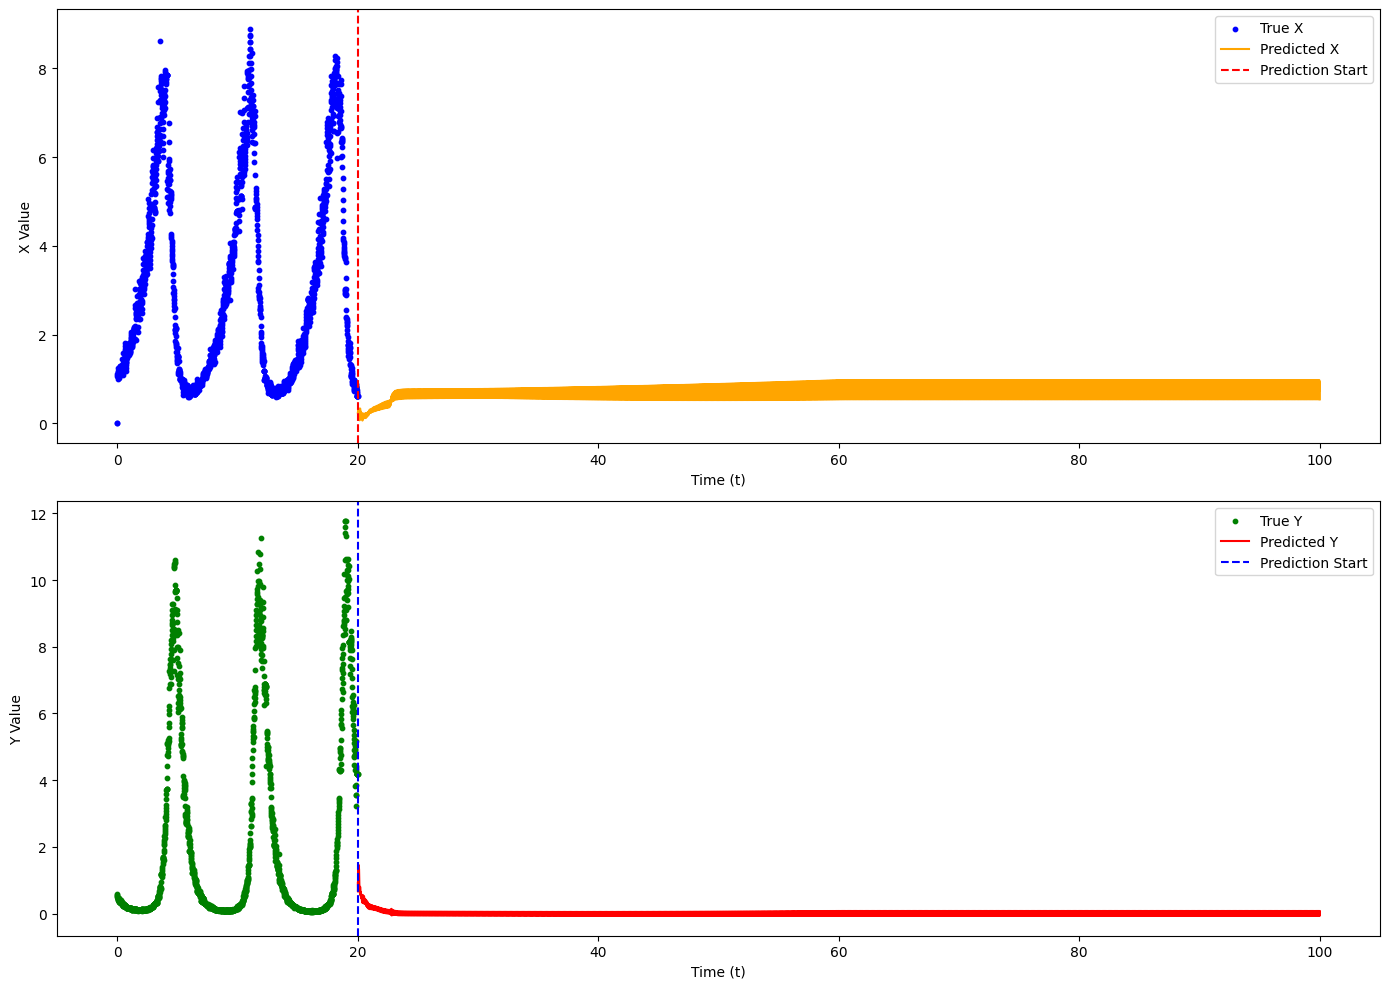

In [23]:
import matplotlib.pyplot as plt

# 原始数据
df_original = pd.read_csv('data.csv')
df_original.replace('-', np.nan, inplace=True)
df_original['t'] = df_original['t'].round(2)
df_original = df_original.drop_duplicates(subset=['t'], keep='first').reset_index(drop=True)
df_original['x'] = df_original['x'].astype(float)
df_original['y'] = df_original['y'].astype(float)

# 生成完整时间步并插值（与预处理步骤一致）
t_full = np.arange(0.00, 20.01, 0.01)
df_full_original = pd.DataFrame({'t': t_full})
df_original = pd.merge(df_full_original, df_original, on='t', how='left')
df_original['x'] = df_original['x'].interpolate(method='linear').fillna(0)
df_original['y'] = df_original['y'].interpolate(method='linear').fillna(0)

plt.figure(figsize=(14, 10))

# 绘制 x(t)
plt.subplot(2, 1, 1)
plt.scatter(df_original['t'], df_original['x'], label='True X', s=10, color='blue')
plt.plot(predictions_df['t'], predictions_df['x'], label='Predicted X', color='orange')
plt.axvline(x=20, color='red', linestyle='--', label='Prediction Start')
plt.xlabel('Time (t)')
plt.ylabel('X Value')
plt.legend()

# 绘制 y(t)
plt.subplot(2, 1, 2)
plt.scatter(df_original['t'], df_original['y'], label='True Y', s=10, color='green')
plt.plot(predictions_df['t'], predictions_df['y'], label='Predicted Y', color='red')
plt.axvline(x=20, color='blue', linestyle='--', label='Prediction Start')
plt.xlabel('Time (t)')
plt.ylabel('Y Value')
plt.legend()

plt.tight_layout()
plt.show()
